In [1]:
import eos
import numpy as np
import yaml
import logging
eos.logger.setLevel(logging.ERROR)

In [2]:
def weighted_average(values, weights, axis=0):
    average = np.average(values, weights=weights, axis=axis)
    variance = np.average((values-average)**2, weights=weights, axis=axis)
    return np.array((average, np.sqrt(variance)))

In [3]:
af = eos.AnalysisFile("analysis_FF.yaml")

In [4]:
for p in af.posteriors:
    data = eos.ImportanceSamples(f"data/{p}/samples")
    K892_samples = data.samples[:,(-4,-3)] * 1000 # convert to MeV
    K892_weights = data.weights
    central = np.average(K892_samples, weights=K892_weights, axis=0)
    cov = np.cov(K892_samples.T, aweights=K892_weights)
    unc = np.sqrt(np.diag(cov))
    cor = cov / np.outer(unc, unc)
    print(f"{p}: M_892 = {central[0]:.2f} ± {unc[0]:#.2g} MeV, Gamma_892 = {central[1]:.2f} ± {unc[1]:.2g} MeV, rho = {cor[0,1]:.2g}")

FF_2_2_3_3: M_892 = 891.72 ± 0.19 MeV, Gamma_892 = 45.10 ± 0.38 MeV, rho = -0.17
FF_2_2_4_4: M_892 = 891.87 ± 0.18 MeV, Gamma_892 = 45.52 ± 0.41 MeV, rho = -0.11
FF_3_2_4_4: M_892 = 891.92 ± 0.19 MeV, Gamma_892 = 44.31 ± 0.36 MeV, rho = -0.12
FF_3_2_5_5: M_892 = 891.83 ± 0.18 MeV, Gamma_892 = 45.01 ± 0.39 MeV, rho = -0.13


In [5]:
for p in af.posteriors:
    data = eos.Prediction(f"data/{p}/pred-fp_at_0")
    f0_samples = data.samples[:,0]
    f0_central, f0_err = weighted_average(f0_samples, data.weights)
    print(f"{p}: f_+(0) = {f0_central:.4f} \\pm {f0_err:#.2g}")

FF_2_2_3_3: f_+(0) = 0.9743 \pm 0.0017
FF_2_2_4_4: f_+(0) = 0.9713 \pm 0.0019
FF_3_2_4_4: f_+(0) = 0.9734 \pm 0.0018
FF_3_2_5_5: f_+(0) = 0.9755 \pm 0.0017


In [6]:
for p in af.posteriors:
    data = eos.Prediction(f"data/{p}/pred-quadratic_model_parameters")
    central = np.average(data.samples, weights=data.weights, axis=0)
    cov = np.cov(data.samples.T, aweights=data.weights)
    unc = np.sqrt(np.diag(cov))
    cor = cov / np.outer(unc, unc)
    print(p)
    print(f"lambda'_+ = {central[0]:.5f} \\pm {unc[0]:#.2g}, lambda'_0 = {central[1]:.4f} \\pm {unc[1]:#.2g}")
    print(f"lambda''_+ = {central[2]:.7f} \\pm {unc[2]:#.2g}, lambda''_0 = {central[3]:.6f} \\pm {unc[3]:#.2g}")
    print(cor)

FF_2_2_3_3
lambda'_+ = 0.02182 \pm 0.00018, lambda'_0 = 0.0136 \pm 0.00069
lambda''_+ = 0.0010675 \pm 8.5e-06, lambda''_0 = 0.000699 \pm 4.2e-05
[[ 1.         -0.4082144   0.95123702  0.2725785 ]
 [-0.4082144   1.         -0.33012406  0.31452176]
 [ 0.95123702 -0.33012406  1.          0.2257131 ]
 [ 0.2725785   0.31452176  0.2257131   1.        ]]
FF_2_2_4_4
lambda'_+ = 0.02378 \pm 0.00069, lambda'_0 = 0.0119 \pm 0.0011
lambda''_+ = 0.0011349 \pm 2.6e-05, lambda''_0 = 0.000779 \pm 4.4e-05
[[ 1.         -0.00259944  0.97524403 -0.02649042]
 [-0.00259944  1.         -0.04107229 -0.20560437]
 [ 0.97524403 -0.04107229  1.         -0.00543008]
 [-0.02649042 -0.20560437 -0.00543008  1.        ]]
FF_3_2_4_4
lambda'_+ = 0.02306 \pm 0.00016, lambda'_0 = 0.0129 \pm 0.0010
lambda''_+ = 0.0010813 \pm 9.1e-06, lambda''_0 = 0.000735 \pm 5.8e-05
[[ 1.         -0.03857851  0.98341135  0.17493344]
 [-0.03857851  1.         -0.00986177 -0.37132763]
 [ 0.98341135 -0.00986177  1.          0.13323154]
 [ 0

In [7]:
for p in af.posteriors:
    data = eos.Prediction(f"data/{p}/pred-absf0_at_mDsquared")
    central = np.average(data.samples, weights=data.weights, axis=0)
    cov = np.cov(data.samples.T, aweights=data.weights)
    unc = np.sqrt(np.diag(cov))
    cor = cov / np.outer(unc, unc)
    print(f"{p}: |f0(m_D^2)| = {central[0]:.2f} \\pm {unc[0]:#.2g}, |f0(m_Ds^2)| = {central[1]:.2f} \\pm {unc[1]:#.2g}, rho = {cor[0,1]:.2g}")

FF_2_2_3_3: |f0(m_D^2)| = 1.74 \pm 0.40, |f0(m_Ds^2)| = 1.53 \pm 0.33, rho = 1
FF_2_2_4_4: |f0(m_D^2)| = 1.69 \pm 0.71, |f0(m_Ds^2)| = 1.66 \pm 0.67, rho = 0.99
FF_3_2_4_4: |f0(m_D^2)| = 1.86 \pm 0.55, |f0(m_Ds^2)| = 1.68 \pm 0.51, rho = 0.98
FF_3_2_5_5: |f0(m_D^2)| = 2.32 \pm 0.89, |f0(m_Ds^2)| = 2.37 \pm 0.87, rho = 0.99


In [8]:
for p in af.posteriors:
    data = eos.Prediction(f"data/{p}/pred-absf0_at_mDsquared")
    mD_samples = data.samples[:,0]
    mDs_samples = data.samples[:,1]
    ratio = mD_samples / mDs_samples
    ratio_central, ratio_err = weighted_average(ratio, data.weights)
    print(f"{p}: |f0(m_D^2)|/|f0(m_D_s^2)| = {ratio_central:.2f} \\pm {ratio_err:#.2g}")

FF_2_2_3_3: |f0(m_D^2)|/|f0(m_D_s^2)| = 1.14 \pm 0.033
FF_2_2_4_4: |f0(m_D^2)|/|f0(m_D_s^2)| = 1.02 \pm 0.23
FF_3_2_4_4: |f0(m_D^2)|/|f0(m_D_s^2)| = 1.11 \pm 0.080
FF_3_2_5_5: |f0(m_D^2)|/|f0(m_D_s^2)| = 0.98 \pm 0.19


In [9]:
for p in af.posteriors:
    data = eos.Prediction(f"data/{p}/pred-argf0_at_mDsquared")
    central = np.average(data.samples, weights=data.weights, axis=0)
    central[0] -= np.pi
    cov = np.cov(data.samples.T, aweights=data.weights)
    unc = np.sqrt(np.diag(cov))
    cor = cov / np.outer(unc, unc)
    print(f"{p}: arg(f0(m_D^2)) = {central[0]:.2f} \\pm {unc[0]:#.2g}, arg(f0(m_Ds^2)) = {central[1]:.2f} \\pm {unc[1]:#.2g}, rho = {cor[0,1]:.2g}")

FF_2_2_3_3: arg(f0(m_D^2)) = -1.73 \pm 0.39, arg(f0(m_Ds^2)) = 1.53 \pm 0.37, rho = 1
FF_2_2_4_4: arg(f0(m_D^2)) = 0.20 \pm 2.5, arg(f0(m_Ds^2)) = 3.08 \pm 2.6, rho = 0.82
FF_3_2_4_4: arg(f0(m_D^2)) = -1.38 \pm 1.6, arg(f0(m_Ds^2)) = 1.63 \pm 1.4, rho = 0.72
FF_3_2_5_5: arg(f0(m_D^2)) = 1.36 \pm 1.6, arg(f0(m_Ds^2)) = 4.61 \pm 1.7, rho = 0.83


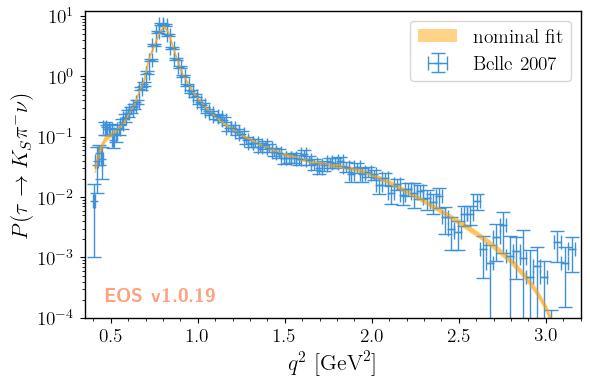

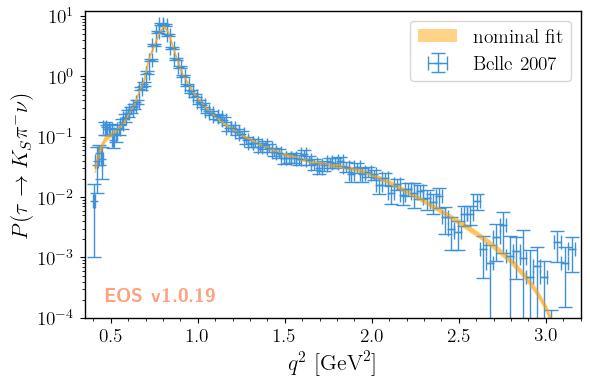

In [ ]:
with open("figures/tau-differential-data.yaml") as f:
    tau_plot_args = yaml.safe_load(f)
for format in ("pdf", "png"):
    fig = eos.figure.FigureFactory.from_dict(**tau_plot_args)
    fig.draw(output=f"figures/tau-differential-data.{format}")